In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, LassoCV, RidgeCV, LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline 
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.datasets import make_regression

In [23]:
df = pd.read_pickle("data/refractive_index.pkl")

# Deixando índices na ordem certa
indices = range(len(df))
df.index = indices

y = df.pop("Indice de Refração")

In [25]:
mat_contagem = {}
for material in df.columns:
    contagem = (df[material] != 0).sum()
    mat_contagem[material] = contagem

ordenado_mat = sorted(mat_contagem.keys(), key= lambda x: mat_contagem[x])

mat_extremos = {
    "Material": [],
    "Frequência": [],
    "Frequência (%)": [],
    "Composição em média (%)": []
}

for mat in ordenado_mat[45:50]:
    freq = mat_contagem[mat]
    freq_pctg = f"{freq * 100 / 46135:.{2}g}"
    comp_media_pctg = f"{100 * df[mat].mean():.{2}g}"

    mat_extremos["Material"].append(mat)
    mat_extremos["Frequência"].append(freq)
    mat_extremos["Frequência (%)"].append(freq_pctg)
    mat_extremos["Composição em média (%)"].append(comp_media_pctg)

pd.DataFrame.from_dict(mat_extremos).set_index("Material")

,Frequência,Frequência (%),Composição em média (%)
Material,,,
Sm2O3,249,0.54,2.7
In2O3,255,0.55,2.4
SO3,260,0.56,1.6
Rb2O,288,0.62,8.8
MnO,312,0.68,11


$\ce{H2O}$

In [26]:
conta_freq_maior_1 = 0
for mat in df.columns:
    freq = (df[mat] !=0).sum()
    if freq > 231:
        conta_freq_maior_1 +=1
print(f"Materiais com mais de 231 ocorrências: {conta_freq_maior_1}")

Materiais com mais de 231 ocorrências: 45


In [5]:
a = pd.read_csv("data/resultado100_ridge.csv")
a

,Unnamed: 0,mse,vies,variancia
0,100.000000,21.352315,1.169653,20.182662
1,105.986982,14.875171,0.949415,13.925755
2,112.332403,7.330400,0.097619,7.232781
3,119.057724,16.773590,0.103358,16.670232
4,126.185688,15.442435,0.519946,14.922488
...,...,...,...,...
95,25060.509655,0.003508,0.003462,0.000046
96,26560.877829,0.003502,0.003459,0.000043
97,28151.072774,0.003503,0.003462,0.000041
98,29836.472403,0.003492,0.003457,0.000035


In [12]:
a = pd.Series(np.logspace(2, 4.5, num=100))

In [1]:
import numpy as np
import pandas as pd
from mlxtend.evaluate import bias_variance_decomp
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler



modelos = ["DummyRegressor", "LinearRegression", "Ridge", "Lasso"]
chaves = ["mse", "vies", "variancia"]

# Gera um dicionário com uma cópia independente das listas para cada modelo
metricas_modelos = {modelo: {chave: [] for chave in chaves} for modelo in modelos}
tamanhos = tuple(map(float, np.logspace(2, 4.5, num=100)))

# Importa DF e amostra
df = pd.read_pickle("data/refractive_index.pkl")
y = df["Indice de Refração"].to_numpy()
X = df.drop(columns=["Indice de Refração"]).to_numpy()

# DIVISAO TREINO-TESTE
SEMENTE = 42
TAMANHO_TESTE = 0.3

X_treino_total, X_teste, y_treino_total, y_teste = train_test_split(
    X, y, test_size=TAMANHO_TESTE, random_state=SEMENTE
)

In [4]:
a = list(X_treino_total)

In [7]:
b = list(map(lambda x: x[0], a))

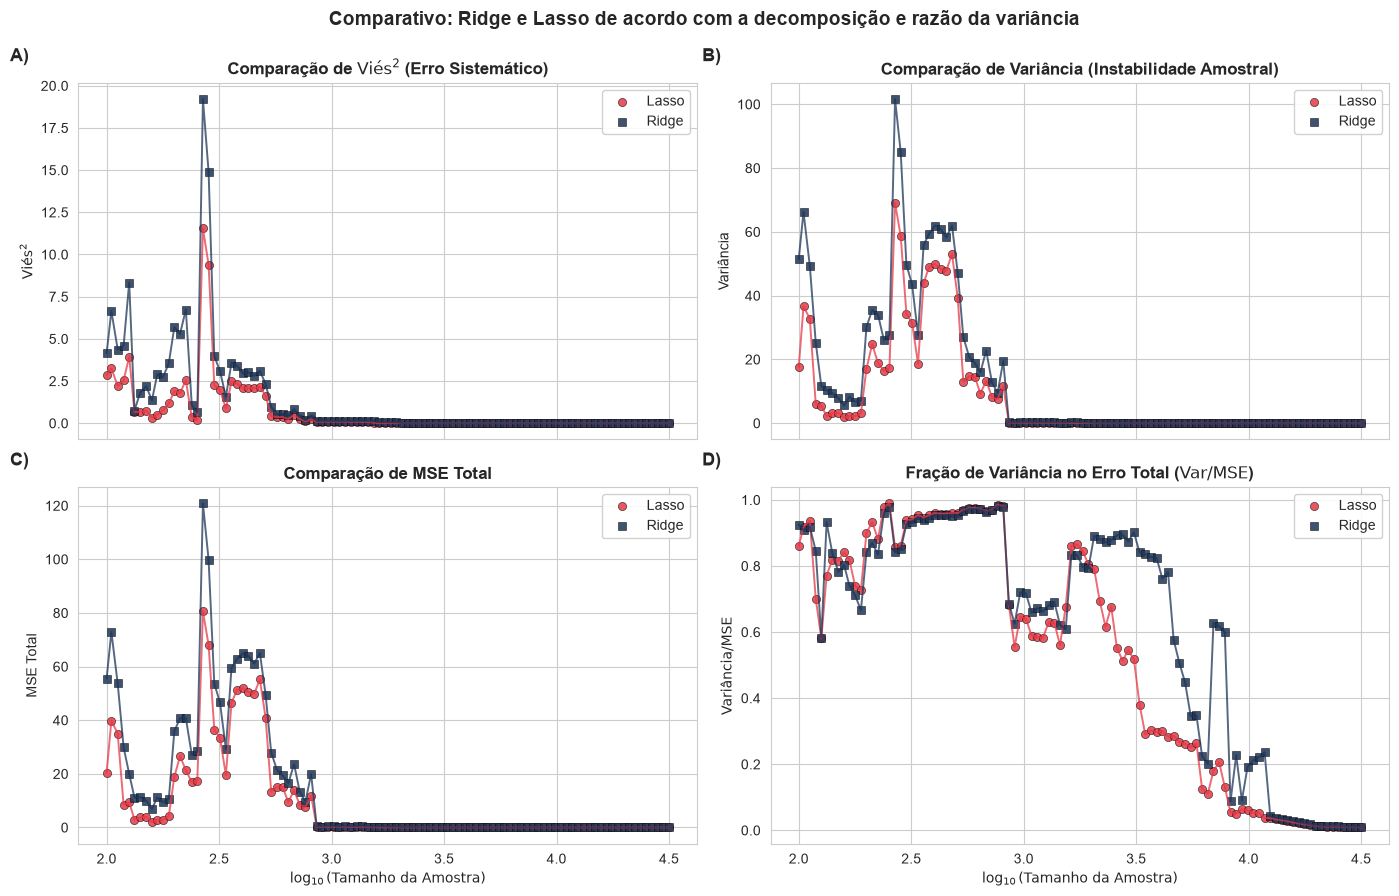

In [19]:
import string
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.close("all")

# 1. Carregamento dos dados
df_lasso = pd.read_csv("data/res_atd_lasso.csv", index_col=0)
df_ridge = pd.read_csv("data/res_atd_ridge.csv", index_col=0)

# 2. Cálculo da métrica derivada: Razão Variância / MSE
df_lasso["razao_var_mse"] = df_lasso["variancia"] / df_lasso["mse"]
df_ridge["razao_var_mse"] = df_ridge["variancia"] / df_ridge["mse"]

x_log_lasso = np.log10(df_lasso.index)
x_log_ridge = np.log10(df_ridge.index)

# 3. Configuração dos estilos visuais dos modelos
modelos = {
    "Lasso": {"df": df_lasso, "x": x_log_lasso, "cor": "#e63946", "marcador": "o"},
    "Ridge": {"df": df_ridge, "x": x_log_ridge, "cor": "#1d3557", "marcador": "s"},
}

# 4. Configuração dos 4 quadrantes
layout_quadrantes = [
    ("vies", r"$\text{Viés}^2$", r"Comparação de $\text{Viés}^2$ (Erro Sistemático)"),
    ("variancia", "Variância", "Comparação de Variância (Instabilidade Amostral)"),
    ("mse", "MSE Total", "Comparação de MSE Total"),
    (
        "razao_var_mse",
        r"$\text{Variância} / \text{MSE}$",
        r"Fração de Variância no Erro Total ($\text{Var} / \text{MSE}$)",
    ),
]

with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
    axes_flat = axes.flatten()

    for idx, (ax, (coluna, label_y, titulo)) in enumerate(zip(axes_flat, layout_quadrantes)):
        for nome_modelo, dados in modelos.items():
            sns.scatterplot(
                x=dados["x"],
                y=dados["df"][coluna],
                ax=ax,
                label=nome_modelo,
                marker=dados["marcador"],
                color=dados["cor"],
                s=35,
                alpha=0.85,
                edgecolor="black",
                linewidth=0.4,
            )
            sns.lineplot(
                x=dados["x"],
                y=dados["df"][coluna],
                ax=ax,
                color=dados["cor"],
                linewidth=1.4,
                alpha=0.75,
            )

        # Rótulo de identificação (A, B, C, D) no canto superior esquerdo
        letra = string.ascii_uppercase[idx]
        ax.text(
            -0.08, 1.05, f"{letra})",
            transform=ax.transAxes,
            fontsize=13,
            weight="bold",
            va="bottom",
            ha="right"
        )

        ax.set_title(titulo, fontsize=12, weight="bold")
        ax.set_ylabel(label_y, fontsize=10)
        ax.set_xlabel(r"$\log_{10}(\text{Tamanho da Amostra})$", fontsize=10)
        ax.legend(frameon=True, facecolor="white", framealpha=0.9)

    plt.suptitle(
        "Comparativo: Ridge e Lasso de acordo com a decomposição e razão da variância",
        fontsize=14,
        weight="bold",
        y=0.99,
    )
    plt.tight_layout()
    plt.show()

plt.close(fig)

In [11]:
df["SiO2"]

0        11.000
1        10.360
2         9.779
3         9.219
4        10.091
          ...  
46237    72.170
46238    72.410
46239    72.400
46240    72.370
46241    72.313
Name: SiO2, Length: 46135, dtype: float64

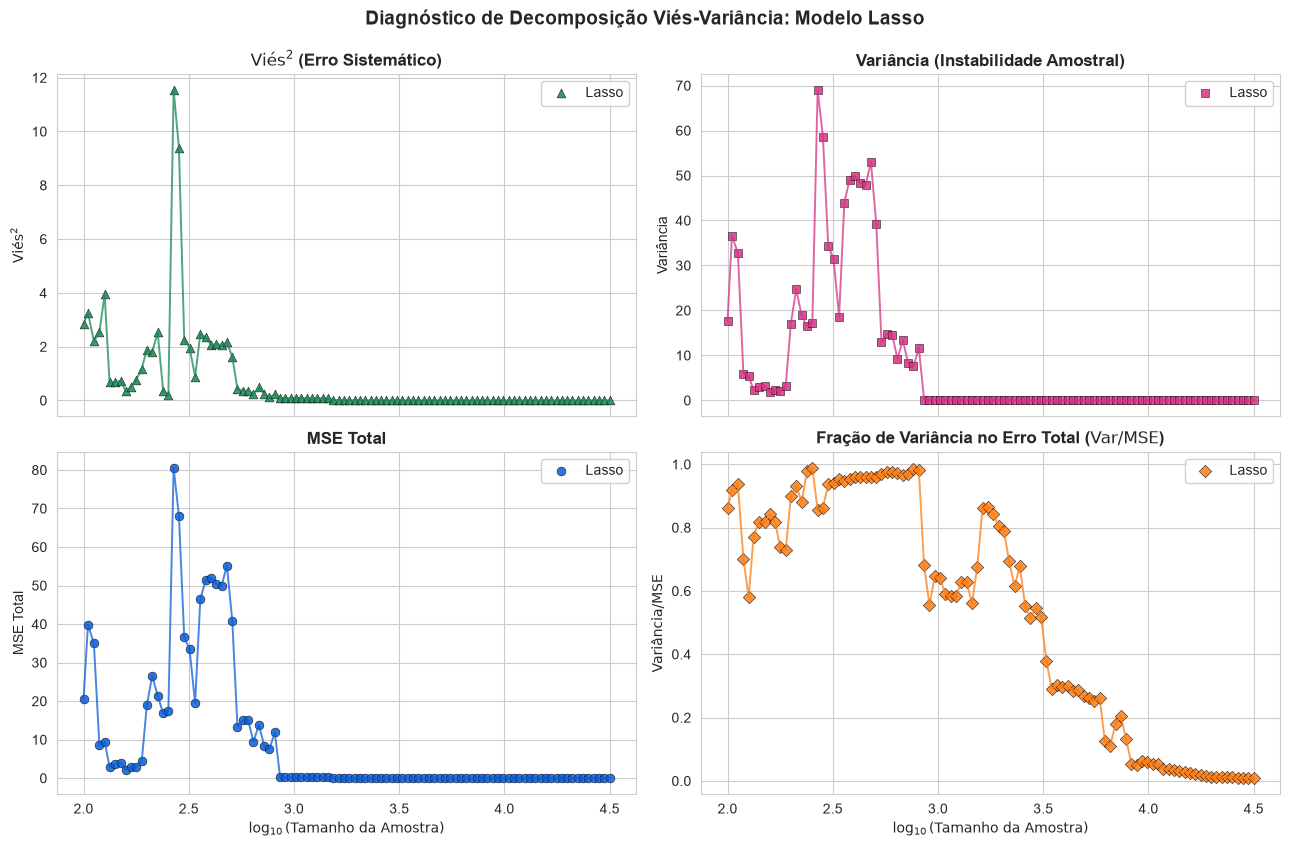

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.close("all")

# 1. Carregamento dos dados
df_lasso = pd.read_csv("data/res_atd_lasso.csv", index_col=0)

# 2. Cálculo da métrica derivada: Razão Variância / MSE
df_lasso["razao_var_mse"] = df_lasso["variancia"] / df_lasso["mse"]

x_log = np.log10(df_lasso.index)

# 3. Definição das métricas por quadrante com cores e marcadores próprios
configuracao_metricas = [
    ("vies", r"$\text{Viés}^2$", r"$\text{Viés}^2$ (Erro Sistemático)", "#198754", "^"),
    ("variancia", "Variância", "Variância (Instabilidade Amostral)", "#d63384", "s"),
    ("mse", "MSE Total", "MSE Total", "#0b5ed7", "o"),
    (
        "razao_var_mse",
        r"$\text{Variância} / \text{MSE}$",
        r"Fração de Variância no Erro Total ($\text{Var} / \text{MSE}$)",
        "#fd7e14",
        "D",
    ),
]

# 4. Construção do grid 2x2 isolado para o Lasso
with sns.axes_style("whitegrid"):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True)
    axes_flat = axes.flatten()

    for ax, (coluna, label_y, titulo, cor, marcador) in zip(
        axes_flat, configuracao_metricas
    ):
        sns.scatterplot(
            x=x_log,
            y=df_lasso[coluna],
            ax=ax,
            marker=marcador,
            color=cor,
            s=40,
            alpha=0.85,
            edgecolor="black",
            linewidth=0.4,
            label="Lasso",
        )
        sns.lineplot(
            x=x_log,
            y=df_lasso[coluna],
            ax=ax,
            color=cor,
            linewidth=1.4,
            alpha=0.75,
        )

        ax.set_title(titulo, fontsize=12, weight="bold")
        ax.set_ylabel(label_y, fontsize=10)
        ax.set_xlabel(r"$\log_{10}(\text{Tamanho da Amostra})$", fontsize=10)
        ax.legend(frameon=True, facecolor="white", framealpha=0.9)

    plt.suptitle(
        "Diagnóstico de Decomposição Viés-Variância: Modelo Lasso",
        fontsize=14,
        weight="bold",
        y=0.99,
    )
    plt.tight_layout()
    plt.show()

plt.close(fig)

In [36]:
scaler = StandardScaler()
X_cols = [c for c in df.columns if c != "Indice de Refração"]
X_scaled = scaler.fit_transform(df[X_cols])

# 2. Reconstrói o DataFrame mantendo index e nomes das colunas
df_scaled = pd.DataFrame(X_scaled, columns=X_cols, index=df.index)

# 3. Visualização rápida
df_scaled["SiO2"]

0       -0.628180
1       -0.650263
2       -0.670311
3       -0.689634
4       -0.659545
           ...   
46130    1.482483
46131    1.490764
46132    1.490419
46133    1.489384
46134    1.487417
Name: SiO2, Length: 46135, dtype: float64

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Limpa figuras anteriores da memória
plt.close("all")

df_ridge = pd.read_csv("data/res_atd_ridge.csv", index_col=0)
x_log = np.log10(df_ridge.index)

# Isola os estilos para não interferir em outras células/gráficos
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    # 1. Pontos translúcidos com marcadores distintos para evitar confusão visual
    sns.scatterplot(
        x=x_log,
        y=df_ridge["mse"],
        ax=ax,
        label="MSE",
        marker="o",
        color="#1f77b4",
        alpha=0.8,
        s=30,
    )
    sns.scatterplot(
        x=x_log,
        y=df_ridge["vies"],
        ax=ax,
        label="Viés$^2$",
        marker="^",
        color="#2ca02c",
        alpha=0.8,
        s=30,
    )
    sns.scatterplot(
        x=x_log,
        y=df_ridge["variancia"],
        ax=ax,
        label="Variância",
        marker="s",
        color="#ff7f0e",
        alpha=0.8,
        s=30,
    )

    # 2. Curvas de tendência contínuas conectando os pontos
    sns.lineplot(
        x=x_log,
        y=df_ridge["mse"],
        ax=ax,
        color="#1f77b4",
        linewidth=1.2,
        alpha=0.7,
    )
    sns.lineplot(
        x=x_log,
        y=df_ridge["vies"],
        ax=ax,
        color="#2ca02c",
        linewidth=1.2,
        alpha=0.7,
    )
    sns.lineplot(
        x=x_log,
        y=df_ridge["variancia"],
        ax=ax,
        color="#ff7f0e",
        linewidth=1.2,
        alpha=0.7,
    )

    # Configurações do gráfico
    ax.set_xlabel(r"$\log_{10}(\text{Tamanho da Amostra})$", fontsize=11)
    ax.set_ylabel("Valor da Métrica", fontsize=11)
    ax.set_title("Decomposição Viés-Variância (Ridge)", fontsize=13, weight="bold")
    ax.legend(frameon=True, facecolor="white", framealpha=0.9)
    plt.tight_layout()
    plt.show()

# Libera o objeto da figura após plotar
plt.close(fig)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Limpa figuras anteriores da memória
plt.close("all")

df_lasso = pd.read_csv("data/res_atd_lasso.csv", index_col=0)
x_log = np.log10(df_lasso.index)

# Isola os estilos para não interferir em outras células/gráficos
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    # 1. Pontos translúcidos com marcadores distintos para evitar confusão visual
    sns.scatterplot(
        x=x_log,
        y=df_lasso["mse"],
        ax=ax,
        label="MSE",
        marker="o",
        color="#1f77b4",
        alpha=0.8,
        s=30,
    )
    sns.scatterplot(
        x=x_log,
        y=df_lasso["vies"],
        ax=ax,
        label="Viés$^2$",
        marker="^",
        color="#2ca02c",
        alpha=0.8,
        s=30,
    )
    sns.scatterplot(
        x=x_log,
        y=df_lasso["variancia"],
        ax=ax,
        label="Variância",
        marker="s",
        color="#ff7f0e",
        alpha=0.8,
        s=30,
    )

    # 2. Curvas de tendência contínuas conectando os pontos
    sns.lineplot(
        x=x_log,
        y=df_lasso["mse"],
        ax=ax,
        color="#1f77b4",
        linewidth=1.2,
        alpha=0.7,
    )
    sns.lineplot(
        x=x_log,
        y=df_lasso["vies"],
        ax=ax,
        color="#2ca02c",
        linewidth=1.2,
        alpha=0.7,
    )
    sns.lineplot(
        x=x_log,
        y=df_lasso["variancia"],
        ax=ax,
        color="#ff7f0e",
        linewidth=1.2,
        alpha=0.7,
    )

    # Configurações do gráfico
    ax.set_xlabel(r"$\log_{10}(\text{Tamanho da Amostra})$", fontsize=11)
    ax.set_ylabel("Valor da Métrica", fontsize=11)
    ax.set_title("Decomposição Viés-Variância (Lasso)", fontsize=13, weight="bold")
    ax.legend(frameon=True, facecolor="white", framealpha=0.9)

    plt.tight_layout()
    plt.show()

# Libera o objeto da figura após plotar
plt.close(fig)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Limpa figuras anteriores da memória
plt.close("all")

df_rlm = pd.read_csv("data/res_atd_rlm.csv", index_col=0)
x_log = np.log10(df_rlm.index)

# Isola os estilos para não interferir em outras células/gráficos
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    # 1. Pontos translúcidos com marcadores distintos para evitar confusão visual
    sns.scatterplot(
        x=x_log,
        y=df_rlm["mse"],
        ax=ax,
        label="MSE",
        marker="o",
        color="#1f77b4",
        alpha=0.8,
        s=30,
    )
    sns.scatterplot(
        x=x_log,
        y=df_rlm["vies"],
        ax=ax,
        label="Viés$^2$",
        marker="^",
        color="#2ca02c",
        alpha=0.8,
        s=30,
    )
    sns.scatterplot(
        x=x_log,
        y=df_rlm["variancia"],
        ax=ax,
        label="Variância",
        marker="s",
        color="#ff7f0e",
        alpha=0.8,
        s=30,
    )

    # 2. Curvas de tendência contínuas conectando os pontos
    sns.lineplot(
        x=x_log,
        y=df_rlm["mse"],
        ax=ax,
        color="#1f77b4",
        linewidth=1.2,
        alpha=0.7,
    )
    sns.lineplot(
        x=x_log,
        y=df_rlm["vies"],
        ax=ax,
        color="#2ca02c",
        linewidth=1.2,
        alpha=0.7,
    )
    sns.lineplot(
        x=x_log,
        y=df_rlm["variancia"],
        ax=ax,
        color="#ff7f0e",
        linewidth=1.2,
        alpha=0.7,
    )

    # Configurações do gráfico
    ax.set_xlabel(r"$\log_{10}(\text{Tamanho da Amostra})$", fontsize=11)
    ax.set_ylabel("Valor da Métrica", fontsize=11)
    ax.set_title("Decomposição Viés-Variância (RLM)", fontsize=13, weight="bold")
    ax.legend(frameon=True, facecolor="white", framealpha=0.9)

    plt.tight_layout()
    plt.show()

# Libera o objeto da figura após plotar
plt.close(fig)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Limpa figuras anteriores da memória
plt.close("all")

df_baseline = pd.read_csv("data/res_atd_baseline.csv", index_col=0)
x_log = np.log10(df_baseline.index)

# Isola os estilos para não interferir em outras células/gráficos
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(9, 5.5))

    # 1. Pontos translúcidos com marcadores distintos para evitar confusão visual
    sns.scatterplot(
        x=x_log,
        y=df_baseline["mse"],
        ax=ax,
        label="MSE",
        marker="o",
        color="#1f77b4",
        alpha=0.8,
        s=30,
    )
    sns.scatterplot(
        x=x_log,
        y=df_baseline["vies"],
        ax=ax,
        label="Viés$^2$",
        marker="^",
        color="#2ca02c",
        alpha=0.8,
        s=30,
    )
    sns.scatterplot(
        x=x_log,
        y=df_baseline["variancia"],
        ax=ax,
        label="Variância",
        marker="s",
        color="#ff7f0e",
        alpha=0.8,
        s=30,
    )

    # 2. Curvas de tendência contínuas conectando os pontos
    sns.lineplot(
        x=x_log,
        y=df_baseline["mse"],
        ax=ax,
        color="#1f77b4",
        linewidth=1.2,
        alpha=0.7,
    )
    sns.lineplot(
        x=x_log,
        y=df_baseline["vies"],
        ax=ax,
        color="#2ca02c",
        linewidth=1.2,
        alpha=0.7,
    )
    sns.lineplot(
        x=x_log,
        y=df_baseline["variancia"],
        ax=ax,
        color="#ff7f0e",
        linewidth=1.2,
        alpha=0.7,
    )  

    # Configurações do gráfico
    ax.set_xlabel(r"$\log_{10}(\text{Tamanho da Amostra})$", fontsize=11)
    ax.set_ylabel("Valor da Métrica", fontsize=11)
    ax.set_title("Decomposição Viés-Variância (Baseline)", fontsize=13, weight="bold")
    ax.legend(frameon=True, facecolor="white", framealpha=0.9)

    plt.tight_layout()
    plt.show()

# Libera o objeto da figura após plotar
plt.close(fig)
